# Image Denoising using Autoencoder on MNIST

In this notebook, we'll build a denoising autoencoder that learns to remove noise from images. We'll use the MNIST handwritten digits dataset, add Gaussian noise to the images, and train an autoencoder to reconstruct the clean versions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Load and Preprocess the Data

In [2]:
# load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# reshape for conv layers -> (samples, 28, 28, 1)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


## 2. Add Noise to Images

In [3]:
# adding gaussian noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# clip values to stay in [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy training data shape:", x_train_noisy.shape)

Noisy training data shape: (60000, 28, 28, 1)


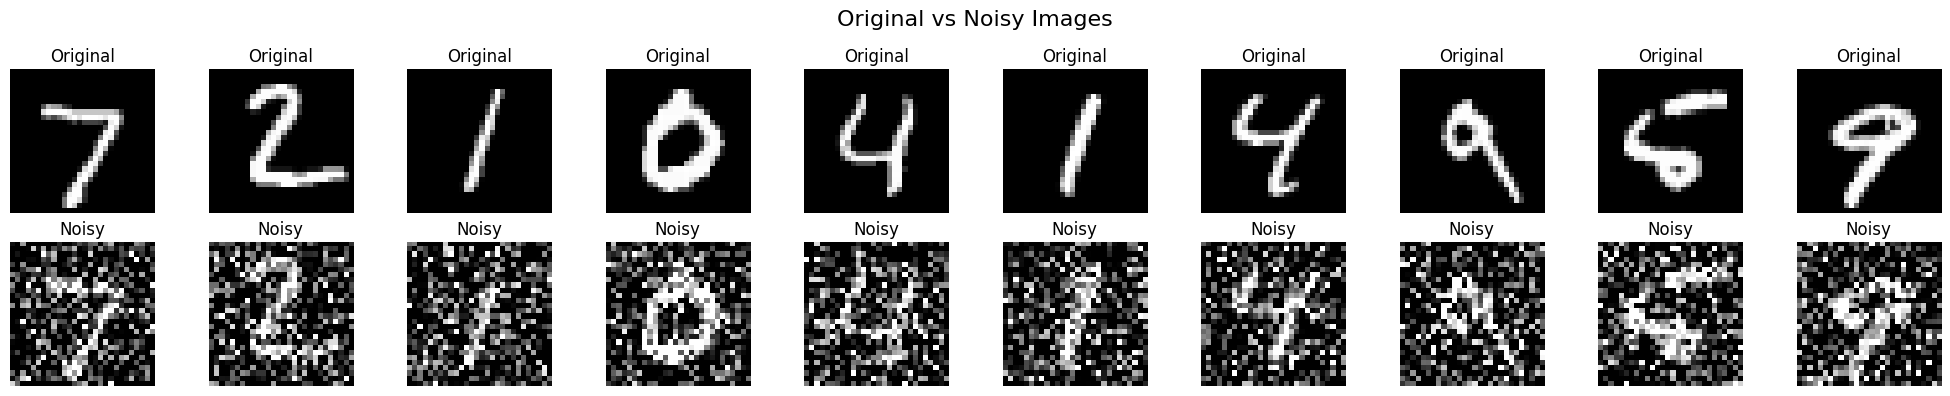

In [4]:
# visualize some noisy vs original images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Images", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Build the Denoising Autoencoder

The autoencoder consists of:
- **Encoder**: Compresses the input image into a lower-dimensional representation using convolutional and pooling layers
- **Decoder**: Reconstructs the clean image from the compressed representation using convolutional and upsampling layers

In [5]:
# Encoder
input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Model

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop]
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.1655 - val_loss: 0.1160
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1128 - val_loss: 0.1082
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1073 - val_loss: 0.1043
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1044 - val_loss: 0.1030
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.1026 - val_loss: 0.1008
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1011 - val_loss: 0.1009
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.1000 - val_loss: 0.0984
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0991 - val_loss: 0.0981
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0984 - val_loss: 0.0973
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0978 - val_loss: 0.0969
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0973 - val_loss: 0.0970
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 

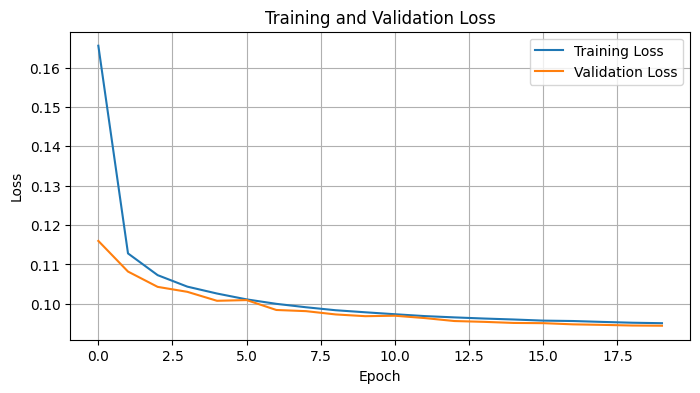

In [7]:
# plot training and validation loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 5. Evaluate and Visualize Results

In [8]:
# predict on test set
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


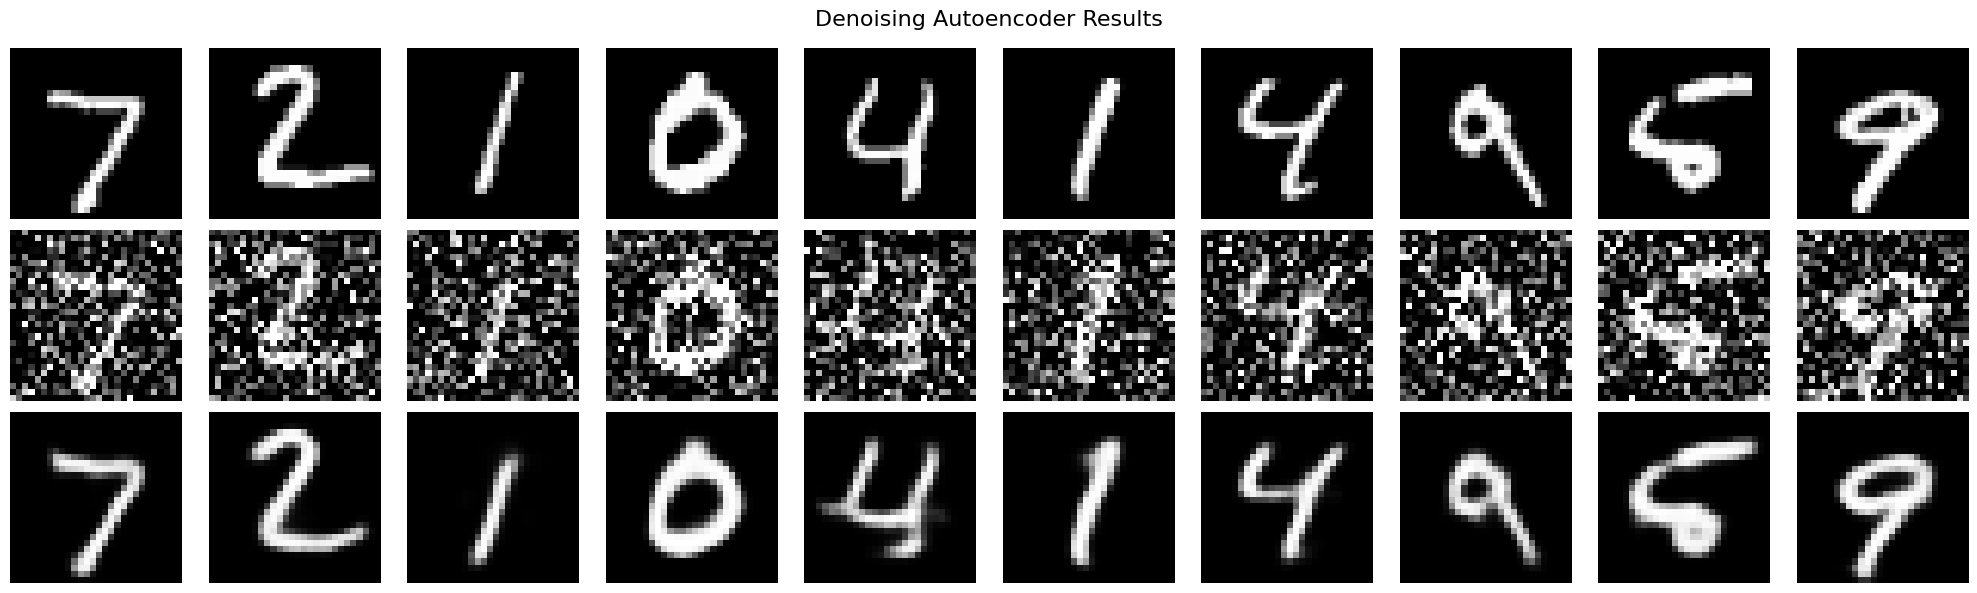

In [9]:
# display original, noisy and denoised images side by side
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    if i == 0:
        plt.ylabel("Original", fontsize=12)
    plt.axis('off')
    
    # noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    if i == 0:
        plt.ylabel("Noisy", fontsize=12)
    plt.axis('off')
    
    # denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    if i == 0:
        plt.ylabel("Denoised", fontsize=12)
    plt.axis('off')

plt.suptitle("Denoising Autoencoder Results", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Quantitative Evaluation

In [10]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# calculate PSNR and SSIM for noisy vs original and denoised vs original
psnr_noisy = np.mean([psnr(x_test[i].squeeze(), x_test_noisy[i].squeeze()) for i in range(len(x_test))])
psnr_denoised = np.mean([psnr(x_test[i].squeeze(), denoised_images[i].squeeze()) for i in range(len(x_test))])

ssim_noisy = np.mean([ssim(x_test[i].squeeze(), x_test_noisy[i].squeeze(), data_range=1.0) for i in range(len(x_test))])
ssim_denoised = np.mean([ssim(x_test[i].squeeze(), denoised_images[i].squeeze(), data_range=1.0) for i in range(len(x_test))])

print(f"Average PSNR (Noisy vs Original): {psnr_noisy:.2f} dB")
print(f"Average PSNR (Denoised vs Original): {psnr_denoised:.2f} dB")
print()
print(f"Average SSIM (Noisy vs Original): {ssim_noisy:.4f}")
print(f"Average SSIM (Denoised vs Original): {ssim_denoised:.4f}")

C:\Users\laksh\AppData\Local\Temp\ipykernel_21940\2840123146.py:5: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr_noisy = np.mean([psnr(x_test[i].squeeze(), x_test_noisy[i].squeeze()) for i in range(len(x_test))])


Average PSNR (Noisy vs Original): 9.38 dB
Average PSNR (Denoised vs Original): 20.11 dB

Average SSIM (Noisy vs Original): 0.3752
Average SSIM (Denoised vs Original): 0.8701


## 7. Testing with Different Noise Levels

Let's see how well the model performs on images with varying amounts of noise.

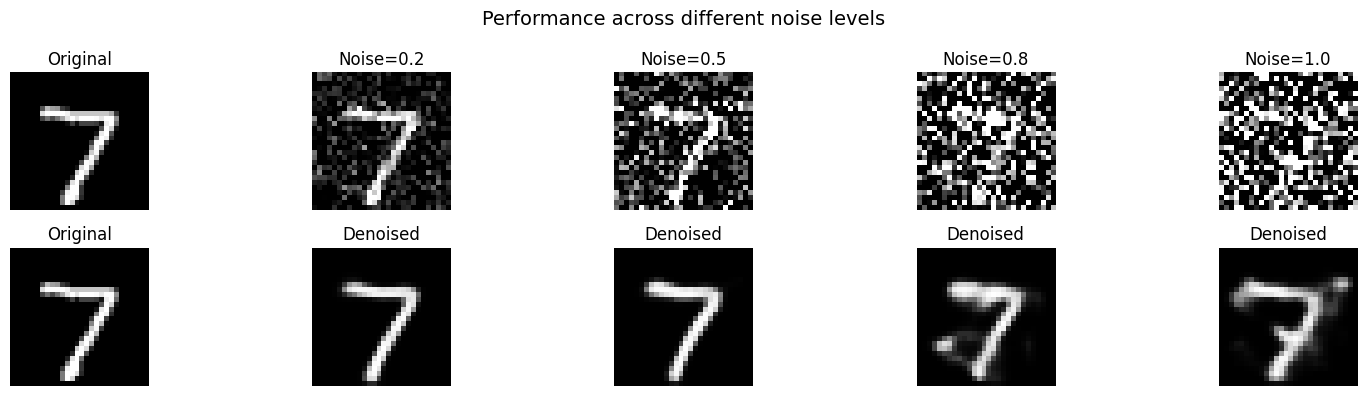

In [11]:
noise_levels = [0.2, 0.5, 0.8, 1.0]
sample_idx = 0

plt.figure(figsize=(16, 4))

# show original first
ax = plt.subplot(2, len(noise_levels) + 1, 1)
plt.imshow(x_test[sample_idx].reshape(28, 28), cmap='gray')
plt.title('Original')
plt.axis('off')

ax = plt.subplot(2, len(noise_levels) + 1, len(noise_levels) + 2)
plt.imshow(x_test[sample_idx].reshape(28, 28), cmap='gray')
plt.title('Original')
plt.axis('off')

for j, nf in enumerate(noise_levels):
    noisy = x_test[sample_idx] + nf * np.random.normal(0, 1, (28, 28, 1))
    noisy = np.clip(noisy, 0., 1.)
    
    denoised = autoencoder.predict(noisy.reshape(1, 28, 28, 1), verbose=0)
    
    ax = plt.subplot(2, len(noise_levels) + 1, j + 2)
    plt.imshow(noisy.reshape(28, 28), cmap='gray')
    plt.title(f'Noise={nf}')
    plt.axis('off')
    
    ax = plt.subplot(2, len(noise_levels) + 1, j + 2 + len(noise_levels) + 1)
    plt.imshow(denoised.reshape(28, 28), cmap='gray')
    plt.title(f'Denoised')
    plt.axis('off')

plt.suptitle('Performance across different noise levels', fontsize=14)
plt.tight_layout()
plt.show()